# Team Name Normalization
# 1. some team names appear in different textual formats(eg. case differences or extra spaces) clean the team1 and team2 columns by
# 2. Converting text to lower cases
# 3. Removing leading/trail spaces
# 4. Verifying unique team names after cleaning

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv('/content/drive/MyDrive/AML_LAB/data.csv')
print(df)

      id  season        city        date                  team1  \
0      1    2008   Bangalore  2008-04-18  Kolkata Knight Riders   
1      2    2008  Chandigarh  2008-04-19    Chennai Super Kings   
2      3    2008       Delhi  2008-04-19       Rajasthan Royals   
3      4    2008      Mumbai  2008-04-20         Mumbai Indians   
4      5    2008     Kolkata  2008-04-20        Deccan Chargers   
..   ...     ...         ...         ...                    ...   
572  573    2016      Raipur  2016-05-22       Delhi Daredevils   
573  574    2016   Bangalore  2016-05-24          Gujarat Lions   
574  575    2016       Delhi  2016-05-25    Sunrisers Hyderabad   
575  576    2016       Delhi  2016-05-27          Gujarat Lions   
576  577    2016   Bangalore  2016-05-29    Sunrisers Hyderabad   

                           team2                  toss_winner toss_decision  \
0    Royal Challengers Bangalore  Royal Challengers Bangalore         field   
1                Kings XI Punjab     

In [6]:
print(df['team1'],df['team2'])

0      Kolkata Knight Riders
1        Chennai Super Kings
2           Rajasthan Royals
3             Mumbai Indians
4            Deccan Chargers
               ...          
572         Delhi Daredevils
573            Gujarat Lions
574      Sunrisers Hyderabad
575            Gujarat Lions
576      Sunrisers Hyderabad
Name: team1, Length: 577, dtype: object 0      Royal Challengers Bangalore
1                  Kings XI Punjab
2                 Delhi Daredevils
3      Royal Challengers Bangalore
4            Kolkata Knight Riders
                  ...             
572    Royal Challengers Bangalore
573    Royal Challengers Bangalore
574          Kolkata Knight Riders
575            Sunrisers Hyderabad
576    Royal Challengers Bangalore
Name: team2, Length: 577, dtype: object


In [7]:
df['team1'] = df['team1'].str.lower().str.strip()
df['team2'] = df['team2'].str.lower().str.strip()
print(df['team1'],df['team2'])

0      kolkata knight riders
1        chennai super kings
2           rajasthan royals
3             mumbai indians
4            deccan chargers
               ...          
572         delhi daredevils
573            gujarat lions
574      sunrisers hyderabad
575            gujarat lions
576      sunrisers hyderabad
Name: team1, Length: 577, dtype: object 0      royal challengers bangalore
1                  kings xi punjab
2                 delhi daredevils
3      royal challengers bangalore
4            kolkata knight riders
                  ...             
572    royal challengers bangalore
573    royal challengers bangalore
574          kolkata knight riders
575            sunrisers hyderabad
576    royal challengers bangalore
Name: team2, Length: 577, dtype: object


In [8]:
print(df['team1'].unique())
print(df['team2'].unique())

['kolkata knight riders' 'chennai super kings' 'rajasthan royals'
 'mumbai indians' 'deccan chargers' 'kings xi punjab'
 'royal challengers bangalore' 'delhi daredevils' 'kochi tuskers kerala'
 'pune warriors' 'sunrisers hyderabad' 'rising pune supergiants'
 'gujarat lions']
['royal challengers bangalore' 'kings xi punjab' 'delhi daredevils'
 'kolkata knight riders' 'rajasthan royals' 'mumbai indians'
 'chennai super kings' 'deccan chargers' 'pune warriors'
 'kochi tuskers kerala' 'sunrisers hyderabad' 'rising pune supergiants'
 'gujarat lions']


# City Name Standardization
# Standardize the city column by:
# 1)Replacing missing city names with "Unknown"
# 2)Converting all city names to title case
# 3)Counting matches played in each city

In [9]:
#before filling the numm / empty value we have to find out how many null values are there
print(df['city'].isnull().sum())

7


In [10]:
import pandas as pd
df["city"] = df["city"].fillna("Unknown")
print(df['city'].isnull().sum())

0


In [11]:
#converting title names in title cases
df["city"] = df["city"].str.title()
print(df['city'].head())

0     Bangalore
1    Chandigarh
2         Delhi
3        Mumbai
4       Kolkata
Name: city, dtype: object


In [ ]:
df['city'].value_counts()

,count
city,
Mumbai,77
Bangalore,58
Kolkata,54
Delhi,53
Chennai,48
Chandigarh,42
Hyderabad,41
Jaipur,33
Pune,25


# Toss Decision Text Analysis
# Analyze the toss_decision column:
# 1)Extract unique decisions
# 2)Count how many times each decision was taken
# 3)Visualize the frequency using a bar chart

In [12]:
#Unique Decisions
df['toss_decision'].unique()

array(['field', 'bat'], dtype=object)

In [13]:
df['toss_decision'].value_counts()


,count
toss_decision,
field,315
bat,262


<Axes: xlabel='toss_decision'>

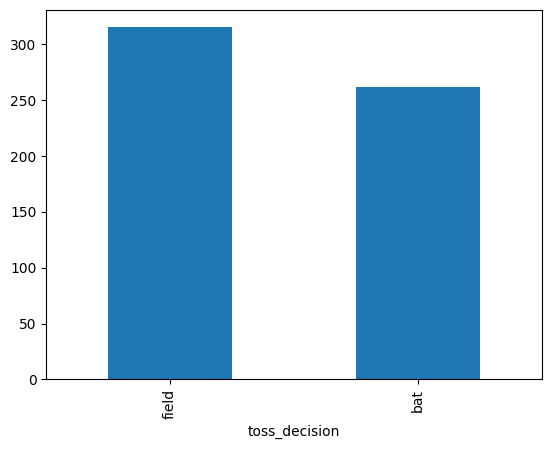

In [15]:
bar = df['toss_decision'].value_counts()
bar.plot(kind='bar')

#  Winner Name Extraction
# From the winner column:
# 1)Identify and remove rows where the match result was "No Result" or "Tie"
# 2)Count how many matches each team won after cleaning text values

In [16]:
df['result'].value_counts()

,count
result,
normal,568
tie,6
no result,3


In [17]:
df = df[df['result'] == "normal"]
df['result'].value_counts()

,count
result,
normal,568


In [18]:
df['winner'].value_counts()

,count
winner,
Mumbai Indians,80
Chennai Super Kings,79
Royal Challengers Bangalore,69
Kolkata Knight Riders,68
Rajasthan Royals,61
Kings XI Punjab,61
Delhi Daredevils,56
Sunrisers Hyderabad,33
Deccan Chargers,29


#  Player of the Match Text Frequency
# Perform text analysis on player of the match:
# 1)Remove null values
# 2)Find the top 10 most frequent player names
# 3)Plot the results using a Seaborn bar plot

In [19]:
top_player = df['player_of_match'].value_counts().head(10)
print(top_player)

player_of_match
CH Gayle          17
YK Pathan         15
AB de Villiers    15
DA Warner         14
RG Sharma         13
SK Raina          13
MS Dhoni          12
MEK Hussey        12
AM Rahane         12
G Gambhir         12
Name: count, dtype: int64


<Axes: ylabel='player_of_match'>

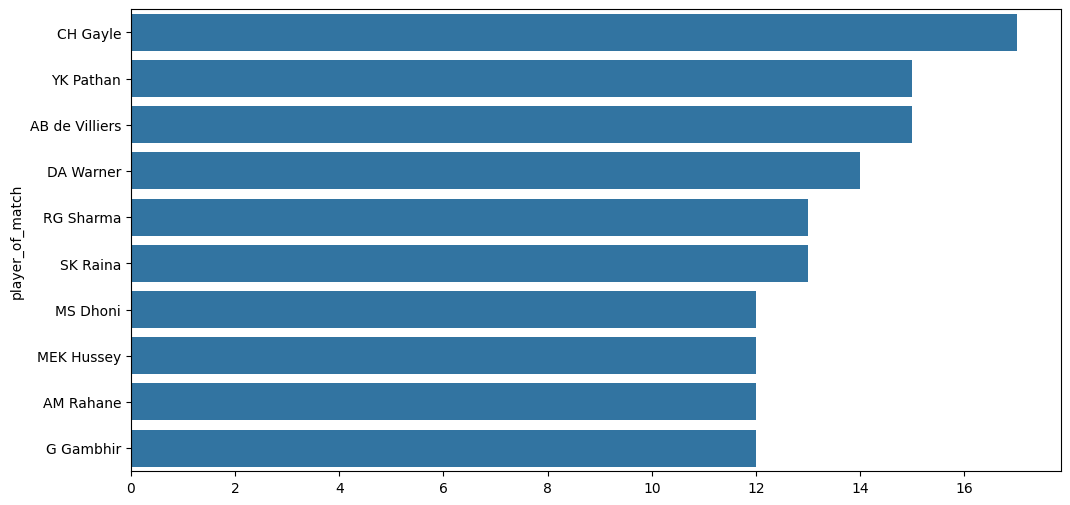

In [20]:
plt.figure(figsize=(12, 6))
sns.barplot(x=top_player.values, y=top_player.index)

# Venue Tokenization
# Count how many matches were played in each venue and plot a bar chart for the top 10.


In [21]:
df['venue'].value_counts().head(10)

,count
venue,
M Chinnaswamy Stadium,55
Eden Gardens,54
Feroz Shah Kotla,52
Wankhede Stadium,49
"MA Chidambaram Stadium, Chepauk",47
"Rajiv Gandhi International Stadium, Uppal",40
"Punjab Cricket Association Stadium, Mohali",35
Sawai Mansingh Stadium,33
Dr DY Patil Sports Academy,17


<Axes: ylabel='count'>

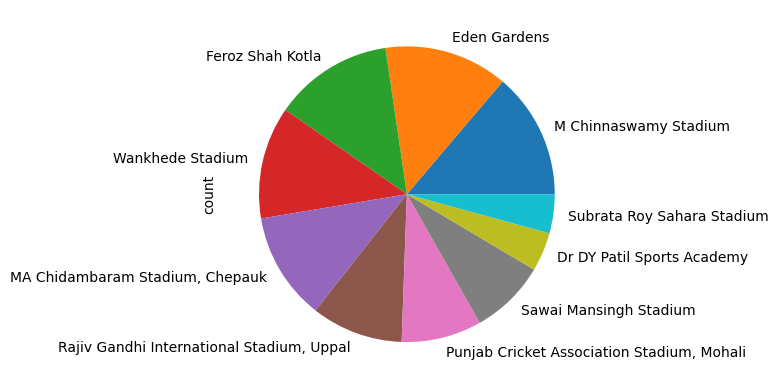

In [22]:
pie = df['venue'].value_counts().head(10)
pie.plot(kind = 'pie')

#  Umpire Name Cleaning
# Clean umpire columns (umpire1, umpire2, umpire3) by:
# 1)Replacing missing values with "Not Assigned"
# 2)Removing duplicate umpire names per match
# 3)Finding the most frequently officiating umpire

In [ ]:
print(df['umpire1'].isnull().sum())
print(df['umpire2'].isnull().sum())
print(df['umpire3'].isnull().sum())

0
0
568


In [ ]:
df['umpire3'].fillna('Not Assigned', inplace = True)

/tmp/ipython-input-3039328278.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['umpire3'].fillna('Not Assigned', inplace = True)
/tmp/ipython-input-3039328278.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Not Assigned' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df['umpire3'].fillna('Not Assigned', inplace = True)


In [ ]:
print(df['umpire1'].isnull().sum())
print(df['umpire2'].isnull().sum())
print(df['umpire3'].isnull().sum())

0
0
0


In [ ]:
umpire1_unique = df['umpire1'].unique()
umpire2_unique = df['umpire2'].unique()

In [ ]:
print(df['umpire1'].head(10))

0    Asad Rauf
1    MR Benson
2    Aleem Dar
3     SJ Davis
4    BF Bowden
5    Aleem Dar
6    IL Howell
7    DJ Harper
8    Asad Rauf
9    Aleem Dar
Name: umpire1, dtype: object


#  Create a new text column match_summary by combining:
# team1, team2, winner, and season
# Example: “MI vs CSK – MI won in 2019”
# Display sample summaries.

In [ ]:
pd.set_option('display.max_colwidth', None)
df['match_summary'] = df['team1'].astype(str) + ' vs ' + df['team2'].astype(str) + ' - ' + df['winner'].astype(str) + ' won in ' + df['season'].astype(str)
print(df['match_summary'].head())

0    Kolkata Knight Riders vs Royal Challengers Bangalore - Kolkata Knight Riders won in 2008
1                    Chennai Super Kings vs Kings XI Punjab - Chennai Super Kings won in 2008
2                         Rajasthan Royals vs Delhi Daredevils - Delhi Daredevils won in 2008
3     Mumbai Indians vs Royal Challengers Bangalore - Royal Challengers Bangalore won in 2008
4                Deccan Chargers vs Kolkata Knight Riders - Kolkata Knight Riders won in 2008
Name: match_summary, dtype: object


#  Result Type Text Analysis
# Analyze the result column:
# Identify different textual result types
# Count their occurrences
# Visualize the distribution using a count plot

In [ ]:
print(df['result'].unique())

['normal']


In [ ]:
print(df['result'].value_counts())

result
normal    568
Name: count, dtype: int64


<Axes: xlabel='result', ylabel='count'>

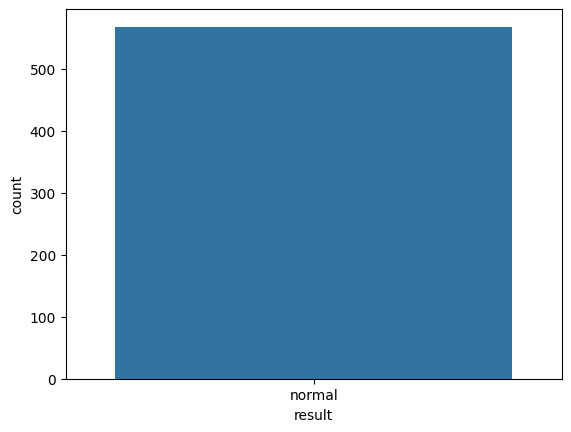

In [ ]:
sns.countplot(x=df['result'])

#  Toss Winner vs Match Winner (Text Matching)
# Compare text values in toss_winner and winner:
# Create a boolean column indicating whether the toss winner also won the match
# Visualize the comparison using a bar chart

In [ ]:
df['toss_winner'] = df['toss_winner'].str.strip().str.lower()
df['winner'] = df['winner'].str.strip().str.lower()
df['toss_won'] = df['toss_winner'] == df['winner']
print(df['toss_won'])

0      False
1       True
2      False
3      False
4      False
       ...  
572     True
573     True
574    False
575     True
576     True
Name: toss_won, Length: 568, dtype: bool


In [ ]:
print(df['toss_won'].value_counts())

toss_won
True     288
False    280
Name: count, dtype: int64


<Axes: xlabel='toss_won'>

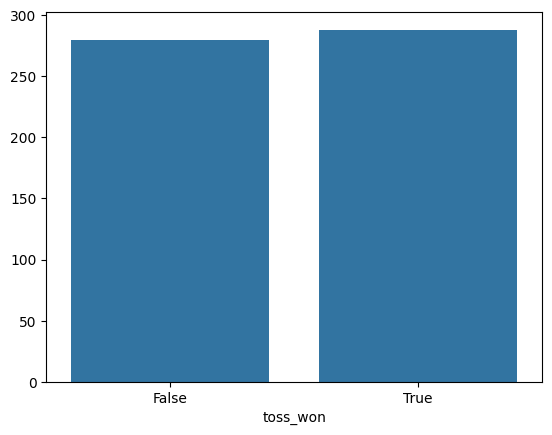

In [ ]:
sns.barplot(x=df['toss_won'].value_counts().index, y=df['toss_won'].value_counts().values)

#  Winner points Graph
# X - team name Y- No. Of win

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
 [Text(0, 0, 'Mumbai Indians'),
  Text(1, 0, 'Chennai Super Kings'),
  Text(2, 0, 'Royal Challengers Bangalore'),
  Text(3, 0, 'Kolkata Knight Riders'),
  Text(4, 0, 'Rajasthan Royals'),
  Text(5, 0, 'Kings XI Punjab'),
  Text(6, 0, 'Delhi Daredevils'),
  Text(7, 0, 'Sunrisers Hyderabad'),
  Text(8, 0, 'Deccan Chargers'),
  Text(9, 0, 'Pune Warriors'),
  Text(10, 0, 'Gujarat Lions'),
  Text(11, 0, 'Kochi Tuskers Kerala'),
  Text(12, 0, 'Rising Pune Supergiants')])

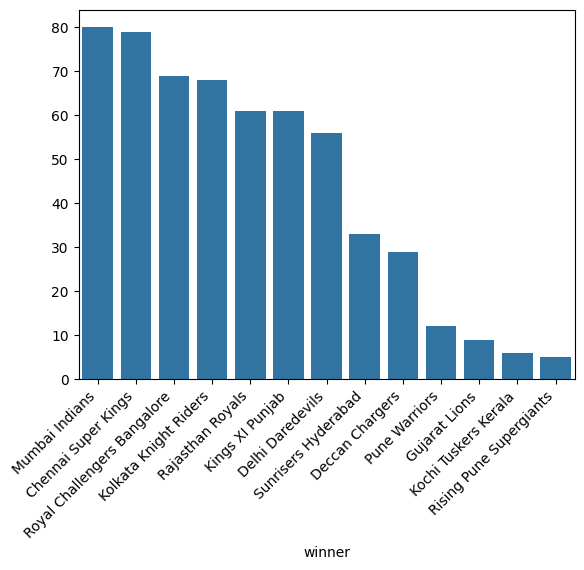

In [24]:
sns.barplot(x=df['winner'].value_counts().index, y=df['winner'].value_counts().values)
plt.xticks(rotation=45 , ha='right')